## AutoLabel Demo: Shoulder Segmentation

This notebook demonstrates how to use the AutoLabel pipeline in interactive mode with a pre-existing YAML configuration (located in config/obj_detection/inference). It loads the configuration for a shoulder dataset and runs the automated labeling process that combines an object detection model with a SAM/SAM2 segmentation model. The demo also showcases several inline visualization examples—using custom callbacks—to inspect both intermediate predictions and the final segmentation overlay.


In [1]:
# ---
# Notebook Setup
# ---

import os
import sys
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# # Set the repository root to the parent folder, because this notebook is in demos/
REPO_ROOT = os.path.abspath("..")
print(REPO_ROOT)

os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

# Import the autolabel function from its module (located in src/obj_detection).
# from src.obj_detection import autolabel
from src.obj_detection.autolabel import run_autolabel
from src.utils.visualization.preprocessing.segmentation_plots import plot_segmentation_overlay


/data/mskprojects/mskSAM/users/ghoyer/backup_repo/AutoMedLabel


In [2]:
import torch

if torch.cuda.is_available():
    print("CUDA is available.")
    print("Number of GPUs:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("CUDA is not available.")


CUDA is available.
Number of GPUs: 1
Current GPU: Tesla V100-SXM3-32GB


In [3]:

def notebook_callback(action, **kwargs):
    if action == "plot_pred":
        # Receive the figure object and display it inline
        fig = kwargs.get("fig")
        if fig is not None:
            display(fig)
            plt.close(fig)  # ensure it's closed after display if needed
    if action == "plot_full":
        # Receive the figure object and display it inline
        fig = kwargs.get("fig")
        if fig is not None:
            display(fig)
            plt.close(fig)

def final_callback(image, mask, save_path, seg_clim, cmap, title, labels_dict):

    def slice_num(data, desired_slices):
        # find non-zero slices
        z_index, _, _ = np.where(data > 0)
        possible_inds = np.unique(z_index)

        num_slices = len(possible_inds)
        step_ = max(1, int(np.ceil(num_slices / desired_slices)))
        start = (num_slices % desired_slices) // 2 if num_slices > desired_slices else 0
        
        return possible_inds[range(start, num_slices, step_)]
    
    slices = slice_num(mask, desired_slices=24)
    fig = plot_segmentation_overlay(vol= image[slices,:,:], 
                        seg= mask[slices,:,:], 
                        save_path=save_path, 
                        seg_clim=seg_clim, 
                        cmap='rainbow', 
                        title="Shoulder Example", #title, 
                        labels_dict=labels_dict,
                        ) 
    if fig is not None:
        display(fig)
        plt.close(fig)


config_file: sam2_hiera_b+.yaml


  0%|          | 0/1 [00:00<?, ?it/s]

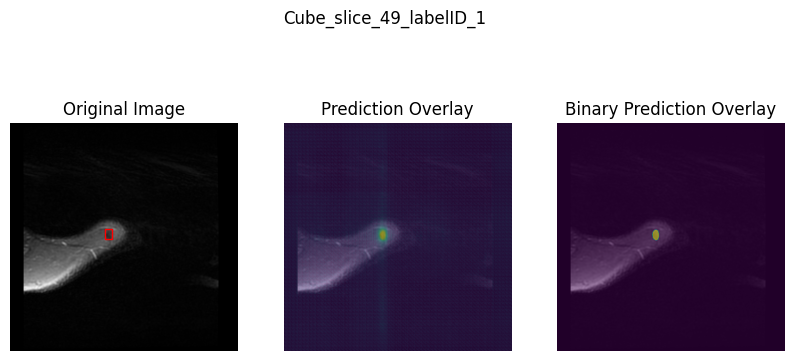

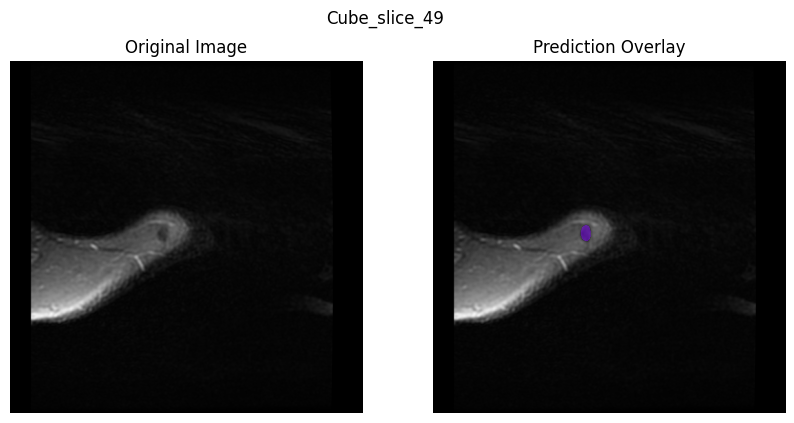

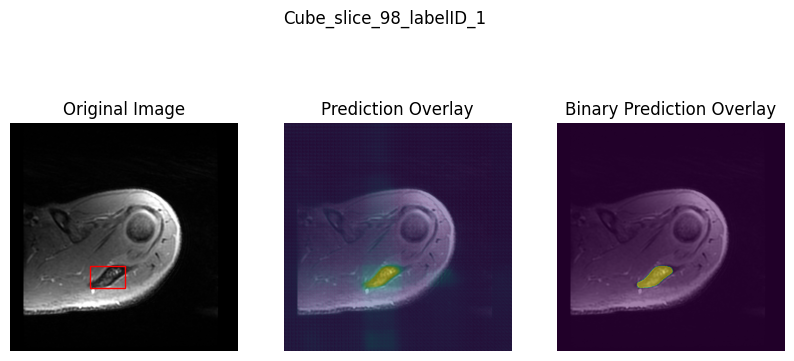

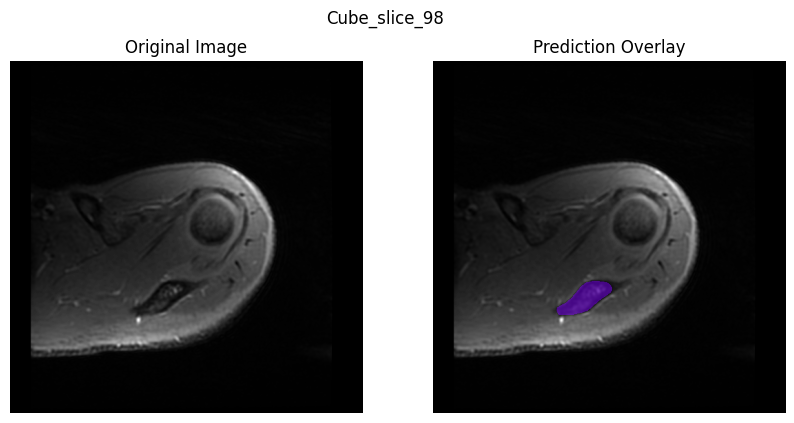

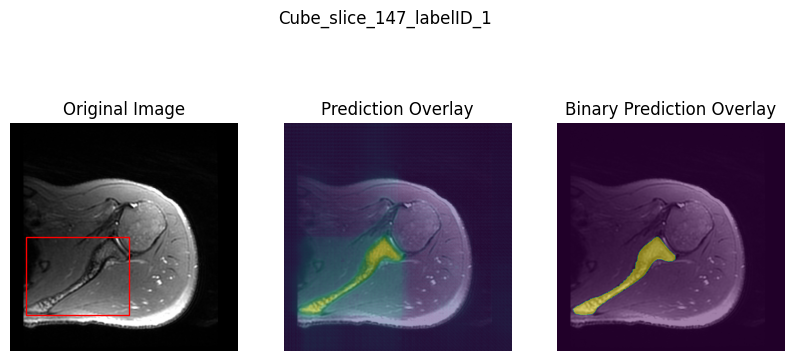

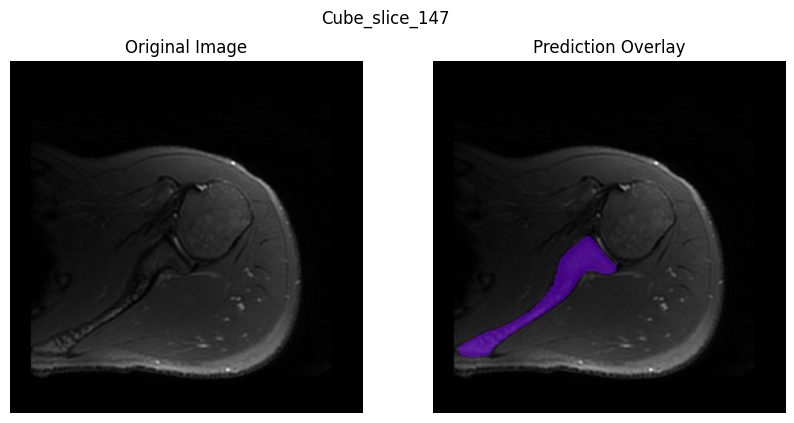

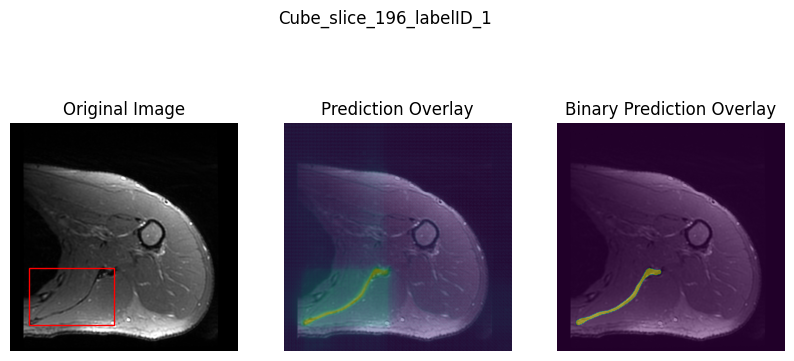

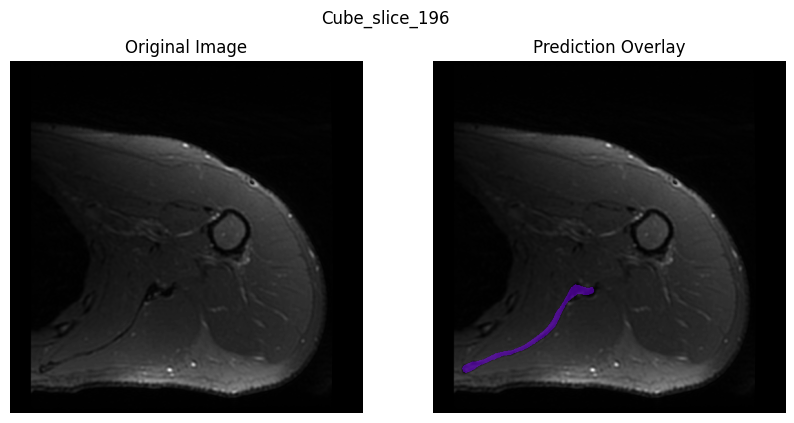

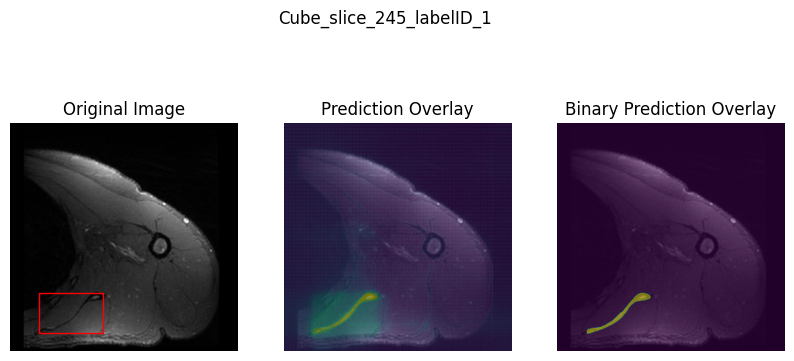

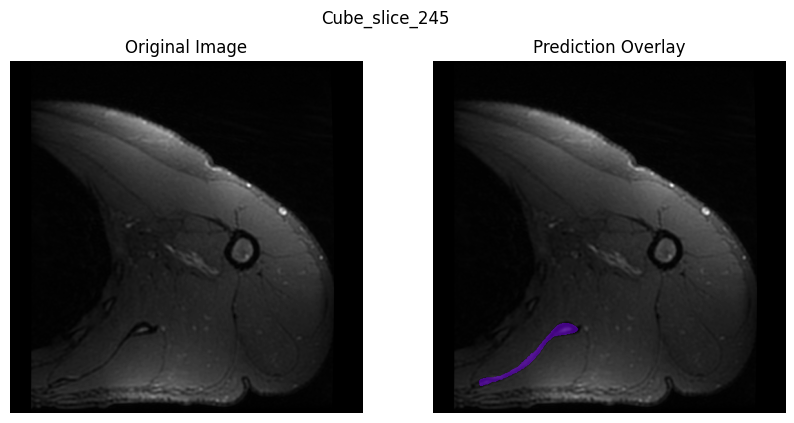

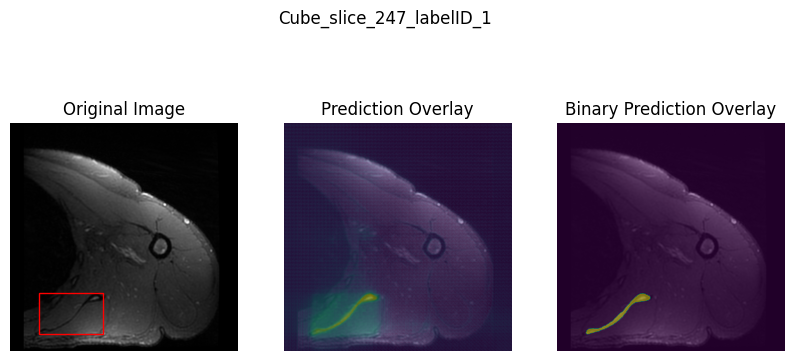

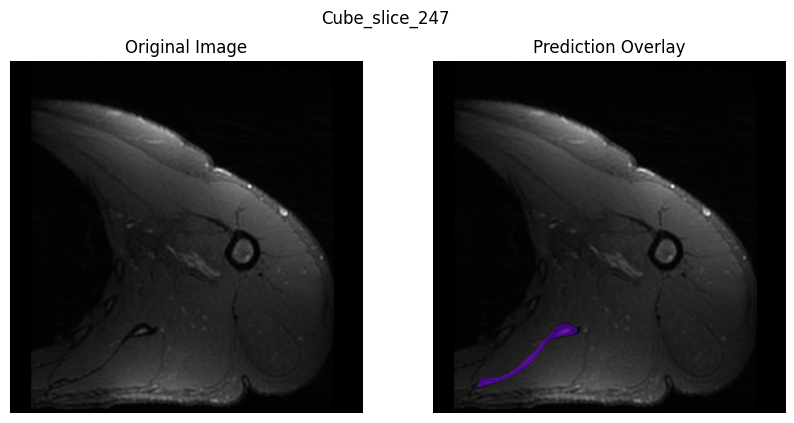

returning fig from plot_segmentation_overlay


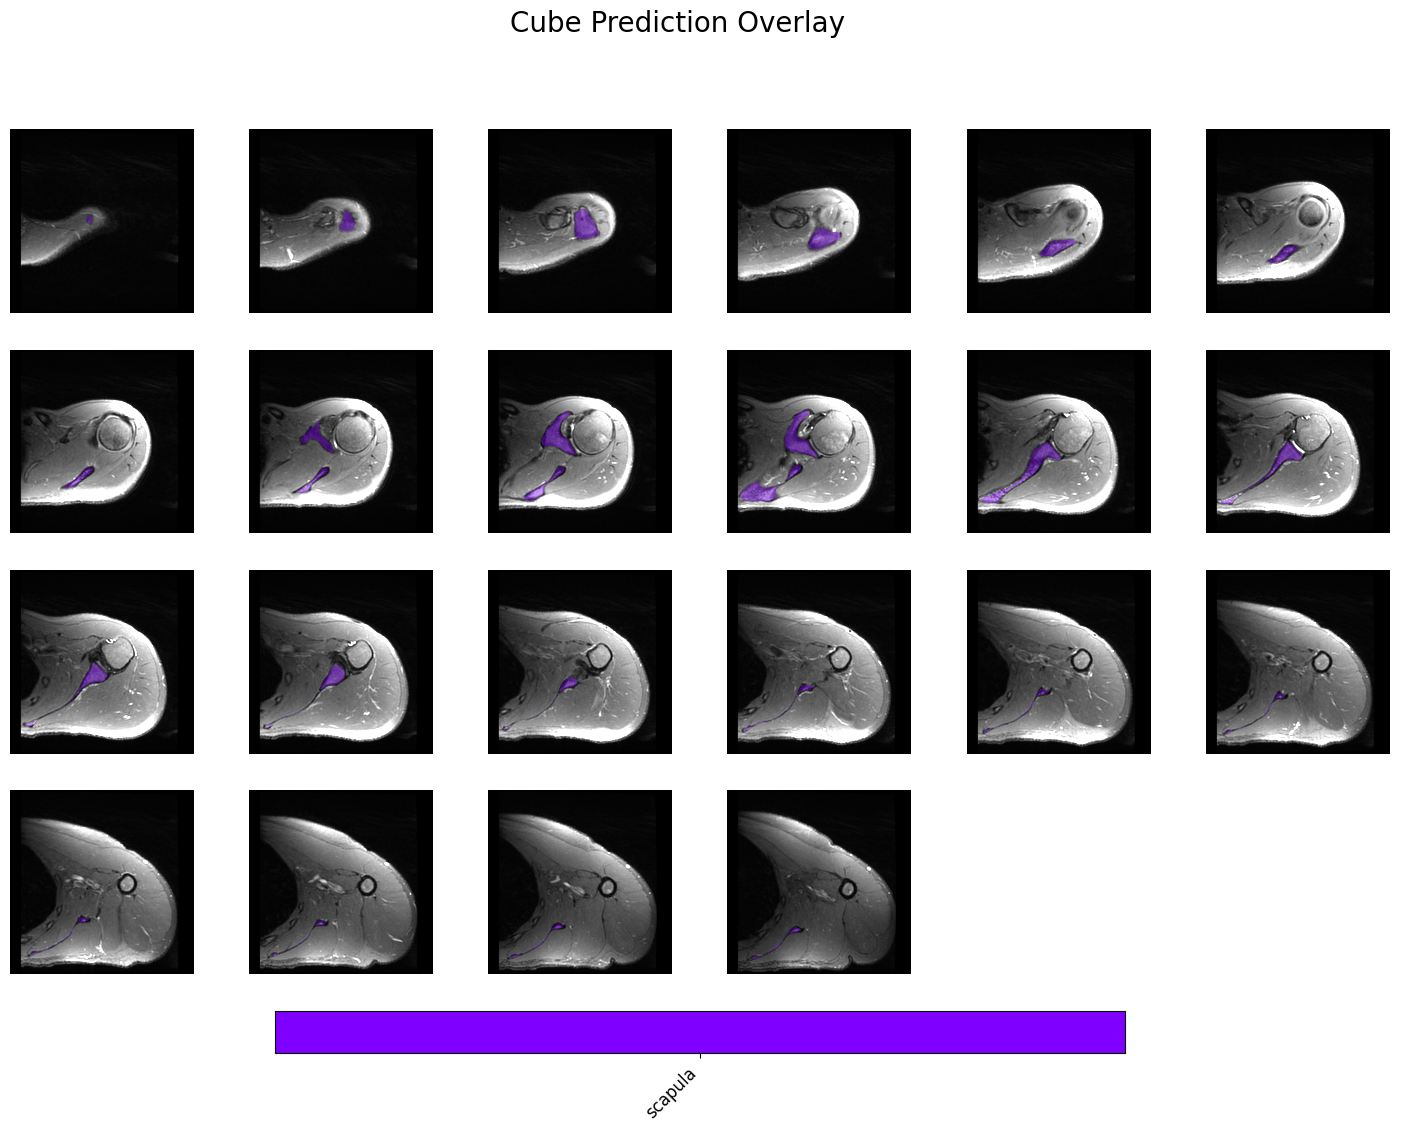

100%|██████████| 1/1 [01:34<00:00, 94.70s/it]


In [ ]:
# ---
# Run AutoLabel
# ---

# config which is placed in /config/obj_detection/inference:
config_name = 'DHAL_Shoulder'
# autolabel.autoLabel(config_name, callback=notebook_callback, final_callback=final_callback)
run_autolabel(config_name, interactive=True, callback=notebook_callback, final_callback=final_callback)
